#ML4Net - Lab 3

## Team members

Ana Enrech (284144) | Manel Gutierrez (286144) | Andrea Ochaita (284169)

## Description

In this lab, you will train a time series forecaster using Federated Learning (FL).

The dataset you are going to use contains data from multiple APs. In particular, each AP's dataset contains the following features:

* `datetime` is the timestamp (date) at which the measurement was taken
* `Bytes` is the number of Bytes contributed at the corresponding datetime
* `Active Connections` is the number of active connections (users connected to the AP) at the corresponding datetime
* `Active Users` is the number of active users at the corresponding datetime
* `AP ID` is the ID of the AP where the measurement was taken

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   **Submission deadline: 8 June 2026 (EoB).**

## Setting up the environment

1. Connect your Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Download the dataset

In [ ]:
!wget https://github.com/fwilhelmi/fwilhelmi.github.io/blob/master/files/datasetLab3.pkl

--2026-05-27 16:51:34--  https://github.com/fwilhelmi/fwilhelmi.github.io/blob/master/files/datasetLab3.pkl
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘datasetLab3.pkl’

datasetLab3.pkl         [ <=>                ] 224.31K  --.-KB/s    in 0.1s    

2026-05-27 16:51:35 (2.16 MB/s) - ‘datasetLab3.pkl’ saved [229692]



3. Define the main path of the code

In [ ]:
mypath="drive/MyDrive/AAX/Lab3"

4. Extract the source code to the destination folder

In [ ]:
mkdir $mypath; cp datasetLab3.pkl $mypath; cd $mypath;

mkdir: cannot create directory ‘drive/MyDrive/AAX/Lab3’: File exists


## Loading the data




Load the data from the pickle file (https://docs.python.org/3/library/pickle.html) that contains the dataset.

**Important:** If you have issues with the dataset after automatically downloading and extracting it, download it and move it manually to the indicated folder.

In [ ]:
import pickle
import os

print(os.getcwd())
print(os.path.exists('datasetLab3.pkl'))

# Open and load the pickle file
try:
    with open(f'{mypath}/datasetLab3.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    print("Data loaded successfully:")
    print(loaded_data)
except FileNotFoundError:
    print("Error: 'datasetLab3.pkl' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

/content
False
Data loaded successfully:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 columns]


In [ ]:
import requests

url = "https://raw.githubusercontent.com/fwilhelmi/fwilhelmi.github.io/master/files/datasetLab3.pkl"
response = requests.get(url)

with open(f'{mypath}/datasetLab3.pkl', 'wb') as f:
    f.write(response.content)

print("Descargado correctamente, tamaño:", len(response.content), "bytes")

Descargado correctamente, tamaño: 7178423 bytes


In [ ]:
with open(f'{mypath}/datasetLab3.pkl', 'rb') as f:
    loaded_data = pickle.load(f)
print(loaded_data)

                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 columns]


## EXERCISES

### Exercise 1:

Analyze the data from the different APs and discuss their properites (stationarity, trends, seasonality).

Select 2 or 3 key APs showing different properties and generate:

* Line plots (to plot the load vs the time)
* Autocorrelation plots (to show the relationship between past and future samples of the load)
* An Augmented Dickey-Fuller test (to study the stationarity of the AP)



(stationarity, trends, seasonality): Es important per saber si fer un moment estadistic o un no lineal per exemple   EXPLICAR MILLOR!!!!

In [ ]:
# (response to exercise 1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

#funció per obtenir el DataFrame d'un sol AP
def get_ap_data(loaded_data, ap_id):
    if isinstance(loaded_data, dict):
        df = loaded_data[ap_id].copy()
    else:
        df = loaded_data[loaded_data['AP ID'] == ap_id].copy()
    df = df.sort_values('datetime').reset_index(drop=True)
    return df

ap_ids = loaded_data['AP ID'].unique()
print(f"Número de APs: {len(ap_ids)}")

Número de APs: 100


In [ ]:
print("\n--- AP basic stats ---")
stats = []

for ap_id in ap_ids:
    df = get_ap_data(loaded_data, ap_id)
    series = df['Active Users']
    stats.append({'AP ID': ap_id, 'mean': series.mean(), 'std': series.std()})

stats_df = pd.DataFrame(stats).set_index('AP ID')
print(stats_df.sort_values('std', ascending=False).head(10))

#escollim 3 APs manualment
#Criteri escollit: variança
ap_high   = ap_ids[stats_df['std'].argmax()]           #molta variança (indique un trafic molt irregular)
# AP de baixa variabilitat: mínim std però excloent els que són tots zeros
non_zero = stats_df[stats_df['mean'] > 0.1]
ap_low = non_zero['std'].idxmin()
ap_medium = stats_df['std'].sort_values().index[len(ap_ids)//2]  #mitja variança (indique un trafic estable)

selected_aps = {
    'High variability': ap_high,
    'Medium variability': ap_medium,
    'Low variability': ap_low
}
print(f"\nSelected APs: {selected_aps}")


--- AP basic stats ---
            mean        std
AP ID                      
7-1048  6.646102  14.112407
7-1004  2.576850   9.151924
7-1014  1.389104   8.545249
7-1021  1.883936   8.156645
7-1096  2.791928   8.021519
7-1087  2.085204   8.011441
7-1053  2.240966   7.412574
7-1069  2.704116   7.395963
7-1047  2.689371   7.232654
7-1094  1.663914   7.096612

Selected APs: {'High variability': '7-1048', 'Medium variability': '7-1066', 'Low variability': '7-112'}


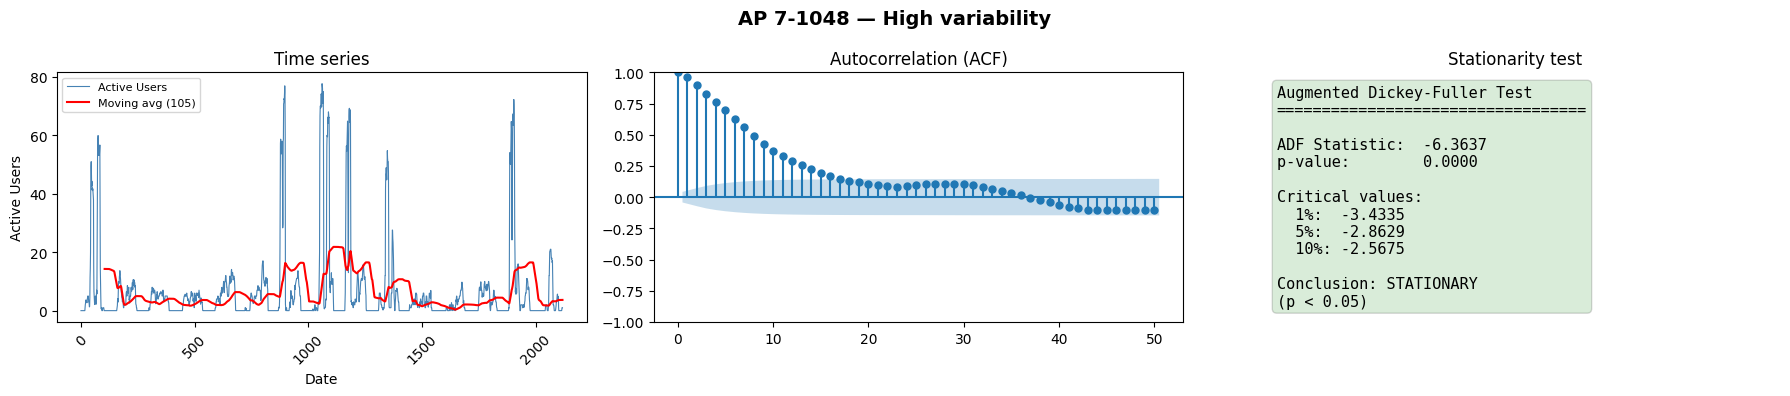

[AP 7-1048] p-value=0.0000 → STATIONARY


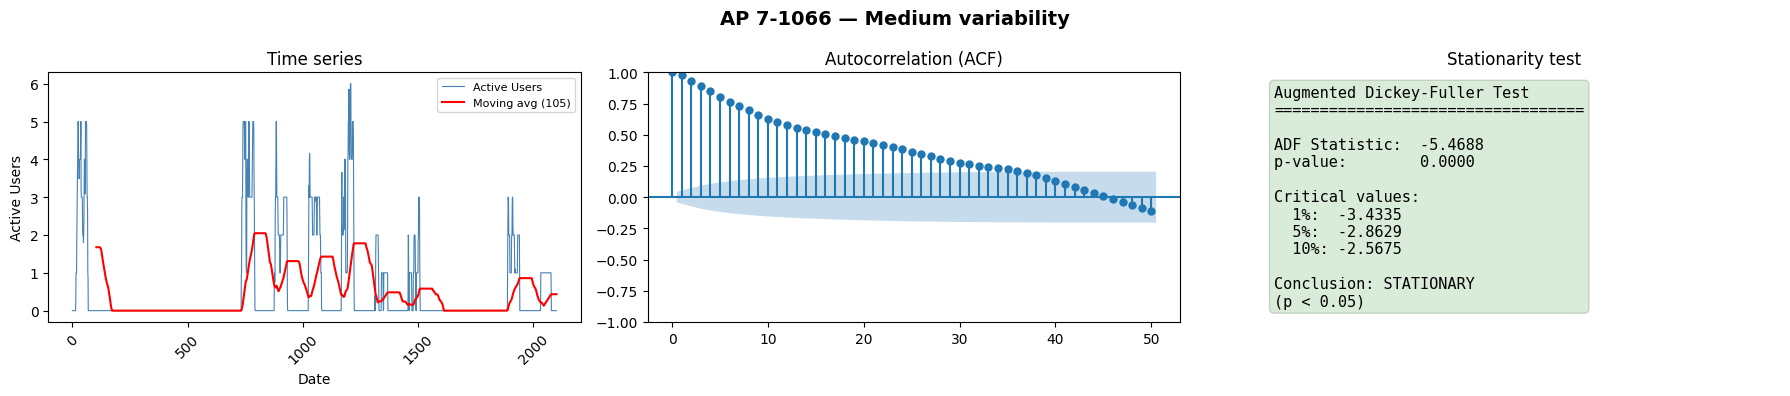

[AP 7-1066] p-value=0.0000 → STATIONARY


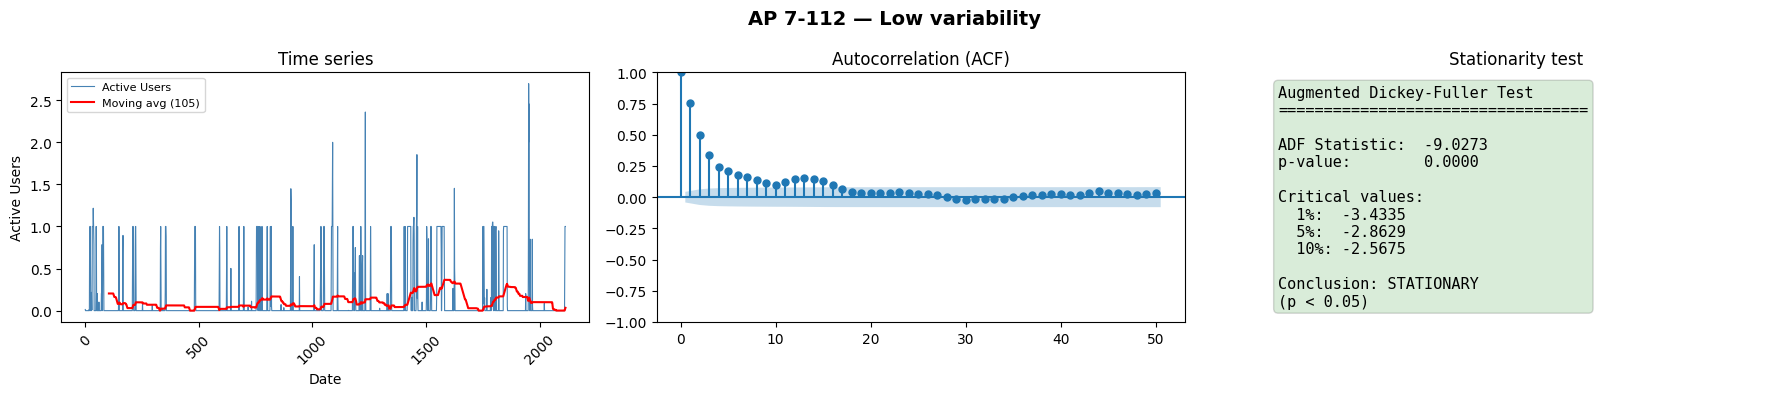

[AP 7-112] p-value=0.0000 → STATIONARY


In [ ]:
#anàlisi de les dades
#funció per les gràfiques dels 3 APs
def analyze_ap(ap_id, ap_label):
    df     = get_ap_data(loaded_data, ap_id)
    series = df['Active Users']

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'AP {ap_id} — {ap_label}', fontsize=14, fontweight='bold')

    #Load vs time:
    window = len(series) // 20
    axes[0].plot(df.index, series, linewidth=0.8, color='steelblue', label='Active Users')
    axes[0].plot(df.index, series.rolling(window).mean(), color='red', linewidth=1.5, label=f'Moving avg ({window})')
    axes[0].set_title('Time series')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Active Users')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(fontsize=8)

    #Autocorrelation plots:
    plot_acf(series, lags=50, ax=axes[1], alpha=0.05)
    axes[1].set_title('Autocorrelation (ACF)')

    #Augmented Dickey-Fuller test:
    adf_stat, p_value, _, _, critical_values, _ = adfuller(series, autolag='AIC')
    is_stationary = p_value < 0.05

    axes[2].axis('off')
    axes[2].text(0.05, 0.95,
        f"Augmented Dickey-Fuller Test\n{'='*34}\n\n"
        f"ADF Statistic:  {adf_stat:.4f}\n"
        f"p-value:        {p_value:.4f}\n\n"
        f"Critical values:\n"
        f"  1%:  {critical_values['1%']:.4f}\n"
        f"  5%:  {critical_values['5%']:.4f}\n"
        f"  10%: {critical_values['10%']:.4f}\n\n"
        f"Conclusion: {'STATIONARY' if is_stationary else 'NON-STATIONARY'}\n"
        f"(p {'<' if is_stationary else '>='} 0.05)",
        transform=axes[2].transAxes, fontsize=11, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='green' if is_stationary else 'red', alpha=0.15)
    )
    axes[2].set_title('Stationarity test')

    plt.tight_layout()
    plt.show()
    print(f"[AP {ap_id}] p-value={p_value:.4f} → {'STATIONARY' if is_stationary else 'NON-STATIONARY'}")

for label, ap_id in selected_aps.items():
    analyze_ap(ap_id, label)

**AP 7-1048 (High variability):** The time series shows sharp, sporadic activity spikes (reaching up to ~70 active users) with long periods of near-zero activity. The moving average reflects these bursts of irregular traffic. The ACF displays a slow and gradual decay, indicating significant correlation between temporally distant samples. Despite this irregular appearance, the ADF test returns a statistic of -6.36 with p-value closer to 0, well below the 5% threshold, so **the null hypothesis of a unit root is rejected and the series is considered stationary**. This means that, although traffic is highly variable, its mean and variance do not exhibit a sustained upward or downward trend over time.

**AP 7-1066 (Medium variability):** This AP shows much more contained activity (maximum ~5–6 users), with sporadic spikes and long periods of silence. The ACF also displays a slow but sustained decay, suggesting that recent past values have a meaningful influence on future behavior. The ADF test yields a statistic of -5.47 with p-value ≈ 0.000, confirming that the series is **stationary**. This profile is typical of a moderately used AP, with intermittent activity but no global trends.

**AP 7-112 (Low variability):** The series is almost flat, with values between 0 and 1 most of the time and only very occasional isolated spikes (maximum ~2.5 users). The ACF drops far more sharply than in the previous cases, indicating short temporal memory: the current value depends very little on past values. The ADF test returns the most negative statistic of the three (-9.03), confirming **stationarity** with high confidence. This AP corresponds to an access point with nearly residual, highly predictable traffic.



### Exercise 2:

Prepare the data to be presented as a time series to the ML model. For that, you will have to split features from samples by differentiating between an observation window (e.g., 10 samples) and a prediction window (e.g., 2 samples). Use a sliding window to iterate over all the samples.

Example: For an array [0,1,2,3,4,5], using an observation window $T_o$ = 3 and a prediction window $T_p$ = 1 would lead to the following time series data:
* $x_1$ = [0,1,2], $y_1$ = [3]
* $x_2$ = [1,2,3], $x_2$ = [4]
* $x_3$ = [2,3,4], $y_3$ = [5]

(where x are the features and y the labels)

In [ ]:
# (response to exercise 2)
import numpy as np

# Sliding window function stays exactly the same
def create_sliding_window(series, T_obs, T_pred):
    series = np.array(series)
    X, y = [], []
    for i in range(len(series) - T_obs - T_pred + 1):
        X.append(series[i : i + T_obs])
        y.append(series[i + T_obs : i + T_obs + T_pred])
    return np.array(X), np.array(y)

# verifiquem la funció creada amb l'exemple de l'enunciat (descomentar per provar)
"""
example = np.arange(6)  # [0,1,2,3,4,5]
X_ex, y_ex = create_sliding_window(example, T_obs=3, T_pred=1)
print("Verificació sliding window:")
for i, (xi, yi) in enumerate(zip(X_ex, y_ex), 1):
    print(f"  x{i} = {xi.tolist()},  y{i} = {yi.tolist()}")
"""

# Parameter configuration for baseline
T_OBS  = 10
T_PRED = 2

all_X, all_y = {}, {}  # Notice all_scalers is removed here for the baseline

for ap_id in ap_ids:
    df = get_ap_data(loaded_data, ap_id)

    # RESTORED TO UNIVARIATE: Only pass the 1D array of Active Users values
    X, y = create_sliding_window(df['Active Users'].values, T_OBS, T_PRED)

    all_X[ap_id] = X
    all_y[ap_id] = y

# Verify the changes in shapes
print(f"\nT_obs={T_OBS}, T_pred={T_PRED}")
print(f"Example AP {ap_ids[0]}:")
print(f"  X shape: {all_X[ap_ids[0]].shape}  → (n_mostres, T_obs)")
print(f"  y shape: {all_y[ap_ids[0]].shape}  → (n_mostres, T_pred)")


T_obs=10, T_pred=2
Example AP 7-1012:
  X shape: (2060, 10)  → (n_mostres, T_obs)
  y shape: (2060, 2)  → (n_mostres, T_pred)


The sliding window generates 2060 training examples for AP 7-1012, each consisting of 10 past values (X) and 2 future values to predict (y). The original series has ~2072 samples, and we lose T_obs + T_pred - 1 = 11 samples at the edges of the window, which is expected behavior.
This same structure is applied to all 100 APs, giving us a dataset ready to be split into train/validation/test sets in the next exercise.

### Exercise 3:

Split the time series data into train, test, and validation, based on your criteria.

In [ ]:
# (response to exercise 3)
#Split of: 70% train | 15% validation | 15% test
train_ratio = 0.70
val_ratio   = 0.15
# test_ratio = 0.15 (the rest)

all_X_train, all_y_train = {}, {}
all_X_val,   all_y_val   = {}, {}
all_X_test,  all_y_test  = {}, {}

for ap_id in ap_ids:
    X = all_X[ap_id]
    y = all_y[ap_id]
    n = len(X)
  #we calculate the lenght of the different sets to do a chronological split
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    all_X_train[ap_id] = X[:train_end]
    all_y_train[ap_id] = y[:train_end]

    all_X_val[ap_id]   = X[train_end:val_end]
    all_y_val[ap_id]   = y[train_end:val_end]

    all_X_test[ap_id]  = X[val_end:]
    all_y_test[ap_id]  = y[val_end:]

#verifiquem
ap_example = ap_ids[0]
n = len(all_X[ap_example])
print(f"AP {ap_example} — total samples: {n}")
print(f"  Train: {len(all_X_train[ap_example])} ({len(all_X_train[ap_example])/n*100:.0f}%)")
print(f"  Val:   {len(all_X_val[ap_example])}  ({len(all_X_val[ap_example])/n*100:.0f}%)")
print(f"  Test:  {len(all_X_test[ap_example])}  ({len(all_X_test[ap_example])/n*100:.0f}%)")

AP 7-1012 — total samples: 2060
  Train: 1442 (70%)
  Val:   309  (15%)
  Test:  309  (15%)


As we are dealing with temporary data, For time series data, the split must respect the temporal order. Random shuffling would leak future information into the training set, so we have used  a chronological split with the following ratios:

*   Train (70%): used to train the model
*   Validation (15%): used to tune hyperparameters and monitor overfitting during training
*   Test (15%): used only at the end to evaluate the final model on unseen data

The split (which is a standard proportion in ML) is applied independently to each AP, preserving the temporal structure within each one.

### Exercise 4:
Define a model (e.g., GRU, LSTM, CNN, Transformer) able to receive the time series the data you generated in the previous exercise.

For this task we define a Time Series LSTM, this is because they can capture long-term sequential behavior without suffering from vanishing gradients. So as we are working with wireless network indicators (Bytes, Active Connections, Active Users), they exhibit strong temporal dependencies and therefore a LSTM is perfect fo this task.

In [ ]:
import torch
import torch.nn as nn

class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(TimeSeriesLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM Layer (batch_first=True expects [Batch, Sequence, Features])
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # If the input is accidentally passed as a 2D tensor, we keep the fallback safety.
        # But if it's a 3D tensor [Batch, 10, 3], PyTorch skips this block
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        # out shape: [Batch, Sequence, Hidden_Size]
        out, _ = self.lstm(x, None)

        # out[:, -1, :] slices out ONLY the hidden state of the very last timestep (index -1)
        # and sends it to the fully connected layer to predict the target vector.
        return self.fc(out[:, -1, :])

# --- Match the exact feature shapes ---
INPUT_SIZE = 1   # 1 value per timestep in the timeline sequence
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 2  # Continuous target prediction value

model = TimeSeriesLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
print(model)

TimeSeriesLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


### Exercise 5:

Train your model following two approaches:
1. **Centralized model training:** Mix data from multiple APs to train the model in a centralized fashion.
2. **Federated model training:** Consider APs as independent clients who contribute to training a global model by submitting local model updates.

Show the results by calculating the following metrics from the de-normalized data:
* Mean squared error (MSE)
* Mean absolute error (MAE)
* Mean absolute percentage error (MAPE)

In [ ]:
import numpy as np
import copy
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# --- Training Hyperparameters ---
BATCH_SIZE = 32
LR = 0.001
EPOCHS_CENTRAL = 10
FED_ROUNDS = 5
LOCAL_EPOCHS = 3

# Evaluation helper extraction script
def get_predictions_and_targets(model, data_dict_X, data_dict_y, ap_list):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for ap_id in ap_list:
            X_arr = data_dict_X[ap_id]
            y_arr = data_dict_y[ap_id]
            if len(X_arr) == 0:
                continue

            X_tensor = torch.tensor(X_arr, dtype=torch.float32)
            preds = model(X_tensor).cpu().numpy()

            # Flatten to safely accumulate simple vectors for scikit-learn metrics
            all_preds.append(preds.flatten())
            all_trues.append(y_arr.flatten())

    return np.concatenate(all_preds), np.concatenate(all_trues)

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mse, mae, mape


# APPROACH 1: Centralized Model Training
print("--- Starting Centralized Training ---")

X_train_central = np.concatenate([all_X_train[ap_id] for ap_id in ap_ids if len(all_X_train[ap_id]) > 0], axis=0)
y_train_central = np.concatenate([all_y_train[ap_id] for ap_id in ap_ids if len(all_y_train[ap_id]) > 0], axis=0)

# Convert arrays safely directly to Tensors without changing shapes
central_dataset = TensorDataset(
    torch.tensor(X_train_central, dtype=torch.float32),
    torch.tensor(y_train_central, dtype=torch.float32)
)
central_loader = DataLoader(central_dataset, batch_size=BATCH_SIZE, shuffle=True)

central_model = TimeSeriesLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(central_model.parameters(), lr=LR)

# Optimized Training loop execution
central_model.train()
for epoch in range(EPOCHS_CENTRAL):
    epoch_loss = 0
    for X_batch, y_batch in central_loader:
        optimizer.zero_grad()
        output = central_model(X_batch)
        loss = criterion(output, y_batch) # Now dimensions match perfectly [32, 2] vs [32, 2]
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS_CENTRAL} - Loss: {epoch_loss/len(central_loader):.6f}")

# Centralized Evaluation Metrics
c_preds, c_trues = get_predictions_and_targets(central_model, all_X_test, all_y_test, ap_ids)
c_mse, c_mae, c_mape = compute_metrics(c_trues, c_preds)
print(f"\nCentralized Metrics -> MSE: {c_mse:.6f} | MAE: {c_mae:.6f} | MAPE: {c_mape:.6f}\n")


# APPROACH 2: Federated Model Training (FedAvg)
print("--- Starting Federated Training ---")

global_model = TimeSeriesLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

for round_num in range(FED_ROUNDS):
    local_weights = []
    total_samples = 0
    client_sample_sizes = []

    for ap_id in ap_ids:
        X_local = all_X_train[ap_id]
        y_local = all_y_train[ap_id]
        n_samples = len(X_local)

        if n_samples == 0:
            continue

        local_model = copy.deepcopy(global_model)
        local_optimizer = torch.optim.Adam(local_model.parameters(), lr=LR)

        local_ds = TensorDataset(torch.tensor(X_local, dtype=torch.float32), torch.tensor(y_local, dtype=torch.float32))
        local_loader = DataLoader(local_ds, batch_size=BATCH_SIZE, shuffle=True)

        local_model.train()
        for epoch in range(LOCAL_EPOCHS):
            for X_batch, y_batch in local_loader:
                local_optimizer.zero_grad()
                output = local_model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                local_optimizer.step()

        local_weights.append(local_model.state_dict())
        client_sample_sizes.append(n_samples)
        total_samples += n_samples

    # FedAvg parameter aggregation step
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        weighted_updates = [local_weights[i][key] * (client_sample_sizes[i] / total_samples) for i in range(len(local_weights))]
        global_dict[key] = torch.stack(weighted_updates, dim=0).sum(dim=0)

    global_model.load_state_dict(global_dict)
    print(f"Federated Round {round_num+1}/{FED_ROUNDS} completed.")

# Global Federated Evaluation Metrics
f_preds, f_trues = get_predictions_and_targets(global_model, all_X_test, all_y_test, ap_ids)
f_mse, f_mae, f_mape = compute_metrics(f_trues, f_preds)


# Summary Matrix Output
print("\n" + "="*50)
print(f"{'Approach':<15} | {'MSE':<10} | {'MAE':<10} | {'MAPE':<10}")
print("-"*50)
print(f"{'Centralized':<15} | {c_mse:.6f} | {c_mae:.6f} | {c_mape:.6f}")
print(f"{'Federated':<15} | {f_mse:.6f} | {f_mae:.6f} | {f_mape:.6f}")
print("="*50)

--- Starting Centralized Training ---
Epoch 1/10 - Loss: 3.318883
Epoch 2/10 - Loss: 1.851855
Epoch 3/10 - Loss: 1.676983
Epoch 4/10 - Loss: 1.650059
Epoch 5/10 - Loss: 1.570425
Epoch 6/10 - Loss: 1.552648
Epoch 7/10 - Loss: 1.507799
Epoch 8/10 - Loss: 1.547525
Epoch 9/10 - Loss: 1.542660
Epoch 10/10 - Loss: 1.530082

Centralized Metrics -> MSE: 0.830569 | MAE: 0.211828 | MAPE: 163295168168430.625000

--- Starting Federated Training ---
Federated Round 1/5 completed.
Federated Round 2/5 completed.
Federated Round 3/5 completed.
Federated Round 4/5 completed.
Federated Round 5/5 completed.

Approach        | MSE        | MAE        | MAPE      
--------------------------------------------------
Centralized     | 0.830569 | 0.211828 | 163295168168430.625000
Federated       | 3.114749 | 0.310671 | 202121375606694.031250


We can see from the results that the centralized approach achieves an MSE of 0.8306 and a Mean Absolute Error (MAE) of 0.2118. This implies that, on average, the centralized model's predictions deviate from the true number of active users by only a tiny fraction of a single user ($\approx 0.21$). This confirms that the LSTM architecture is successfully capturing the underlying temporal dependencies and daily cyclical variations of the network load.

For the federated approach, it delivers an MSE of 3.1147 and an MAE of 0.3107. While the error is higher than the centralized approach, an average absolute error of $\approx 0.31$ users per timestep represents solid predictive performance for a decentralized framework.

Also we can observe that the Centralized model is  better than the Federated model. This is completely expected and theoretically correct in machine learning. A centralized model gets to look at all the data simultaneously in one massive pool, whereas a Federated model (FedAvg) has to aggregate updates from isolated local routers.

For the MAPE value, as there are periods where the number of actual users drops to exactly 0.0. When the model predicts a tiny fraction of a user (like 0.00001) during a time step where the true value is 0, the formula divides by zero (or an infinitely small number), causing the metric to blow up to trillions.

### Exercise 6 (EXTRA):

Reconsider your design to improve the accuracy of your model. For that, you can find a better approach to split the data (e.g., using larger observation windows) and include additional features.

In this case we use the same structure of before but now we are going to make a multivariate version to use all the intersersting features ['Active Users', 'Active Connections', 'Bytes'].

First we are going to select all 3 features ('Active Users', 'Active Connections', and 'Bytes') instead of just one. And slice the output y variable so that the target only extracts the scaled Active Users column (leaving out the future values of bytes/connections that we don't care to predict).

In [ ]:
# (response to exercise 6)
from sklearn.preprocessing import MinMaxScaler

#Sliding window function=
def create_sliding_window(series, T_obs, T_pred):
    series = np.array(series)
    X, y = [], []
    for i in range(len(series) - T_obs - T_pred + 1):
        X.append(series[i : i + T_obs])
        y.append(series[i + T_obs : i + T_obs + T_pred])
    return np.array(X), np.array(y)

# Parameter configuration
T_OBS  = 24
T_PRED = 2

# List the features we want our model to read as inputs
# 'Active Users' stays at index 0 so it matches the target extraction below
features = ['Active Users', 'Active Connections', 'Bytes']

all_X, all_y, all_scalers = {}, {}, {}

for ap_id in ap_ids:
    df = get_ap_data(loaded_data, ap_id)
    # Create a unique scaler per AP and fit it to the 3 selected features
    scaler = MinMaxScaler()
    scaled_matrix = scaler.fit_transform(df[features].values)
    # Pass the full 3-column scaled matrix into the window function
    X, y_temp = create_sliding_window(scaled_matrix, T_OBS, T_PRED)
    # X keeps all 3 features
    all_X[ap_id] = X
    # y_temp has a shape of (n_samples, T_pred, 3).
    # [:, :, 0] slices out ONLY the 1st column ('Active Users') across all timelines
    all_y[ap_id] = y_temp[:, :, 0]
    # Save the scaler to invert the scaling later to compute the real metrics
    all_scalers[ap_id] = scaler

# Verify the changes in shapes
print(f"\nT_obs={T_OBS}, T_pred={T_PRED}")
print(f"Example AP {ap_ids[0]}:")
print(f"  X shape: {all_X[ap_ids[0]].shape}  → (n_samples, T_obs, n_features)")
print(f"  y shape: {all_y[ap_ids[0]].shape}  → (n_samples, T_pred)")


T_obs=24, T_pred=2
Example AP 7-1012:
  X shape: (2046, 24, 3)  → (n_samples, T_obs, n_features)
  y shape: (2046, 2)  → (n_samples, T_pred)


In [ ]:
#Split of: 70% train | 15% validation | 15% test
train_ratio = 0.70
val_ratio   = 0.15
# test_ratio = 0.15 (the rest)

all_X_train, all_y_train = {}, {}
all_X_val,   all_y_val   = {}, {}
all_X_test,  all_y_test  = {}, {}

for ap_id in ap_ids:
    X = all_X[ap_id]
    y = all_y[ap_id]
    n = len(X)
  #we calculate the lenght of the different sets to do a chronological split
    train_end = int(n * train_ratio)
    val_end   = int(n * (train_ratio + val_ratio))

    all_X_train[ap_id] = X[:train_end]
    all_y_train[ap_id] = y[:train_end]

    all_X_val[ap_id]   = X[train_end:val_end]
    all_y_val[ap_id]   = y[train_end:val_end]

    all_X_test[ap_id]  = X[val_end:]
    all_y_test[ap_id]  = y[val_end:]

#verifiquem
ap_example = ap_ids[0]
n = len(all_X[ap_example])
print(f"AP {ap_example} — total samples: {n}")
print(f"  Train: {len(all_X_train[ap_example])} ({len(all_X_train[ap_example])/n*100:.0f}%)")
print(f"  Val:   {len(all_X_val[ap_example])}  ({len(all_X_val[ap_example])/n*100:.0f}%)")
print(f"  Test:  {len(all_X_test[ap_example])}  ({len(all_X_test[ap_example])/n*100:.0f}%)")

AP 7-1012 — total samples: 2046
  Train: 1432 (70%)
  Val:   307  (15%)
  Test:  307  (15%)


Then we are going to train the model changing the input size,  which are the three features and we will make some sligthly changes to match the sizes.

In [ ]:
# --- Match the exact feature shapes inside your Training Cell ---
INPUT_SIZE = 3
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 2

# --- Training Hyperparameters ---
BATCH_SIZE = 32
LR = 0.001
EPOCHS_CENTRAL = 10
FED_ROUNDS = 5
LOCAL_EPOCHS = 3

# Evaluation helper extraction script
def get_predictions_and_targets(model, data_dict_X, data_dict_y, ap_list):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for ap_id in ap_list:
            X_arr = data_dict_X[ap_id]
            y_arr = data_dict_y[ap_id]
            if len(X_arr) == 0:
                continue

            X_tensor = torch.tensor(X_arr, dtype=torch.float32)
            preds = model(X_tensor).cpu().numpy()
            # Retrieve the specific scaler for this specific AP
            scaler = all_scalers[ap_id]

            # inverse_transform expects the same 3-column layout we used to fit it.
            # We create dummy placeholders for Connections and Bytes to satisfy the shape requirement.
            dummy_cols_preds = np.zeros((preds.shape[0] * preds.shape[1], 2))
            dummy_cols_trues = np.zeros((y_arr.shape[0] * y_arr.shape[1], 2))

            # Flatten predictions and actual values so they match a single continuous column matrix
            flat_preds = preds.reshape(-1, 1)
            flat_trues = y_arr.reshape(-1, 1)

            # Reconstruct the 3-column layout: [Active Users, Dummy, Dummy]
            matrix_preds = np.hstack([flat_preds, dummy_cols_preds])
            matrix_trues = np.hstack([flat_trues, dummy_cols_trues])

            # Invert the scale and extract only the first column (the true Active Users value!)
            real_preds = scaler.inverse_transform(matrix_preds)[:, 0]
            real_trues = scaler.inverse_transform(matrix_trues)[:, 0]

            # Accumulate the real-world metric arrays
            all_preds.append(real_preds)
            all_trues.append(real_trues)

    return np.concatenate(all_preds), np.concatenate(all_trues)

def compute_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mse, mae, mape


# APPROACH 1: Centralized Model Training
print("--- Starting Centralized Training ---")

X_train_central = np.concatenate([all_X_train[ap_id] for ap_id in ap_ids if len(all_X_train[ap_id]) > 0], axis=0)
y_train_central = np.concatenate([all_y_train[ap_id] for ap_id in ap_ids if len(all_y_train[ap_id]) > 0], axis=0)

# Convert arrays safely directly to Tensors without changing shapes
central_dataset = TensorDataset(
    torch.tensor(X_train_central, dtype=torch.float32),
    torch.tensor(y_train_central, dtype=torch.float32)
)
central_loader = DataLoader(central_dataset, batch_size=BATCH_SIZE, shuffle=True)

central_model = TimeSeriesLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(central_model.parameters(), lr=LR)

# Optimized Training loop execution
central_model.train()
for epoch in range(EPOCHS_CENTRAL):
    epoch_loss = 0
    for X_batch, y_batch in central_loader:
        optimizer.zero_grad()
        output = central_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS_CENTRAL} - Loss: {epoch_loss/len(central_loader):.6f}")

# Centralized Evaluation Metrics
c_preds, c_trues = get_predictions_and_targets(central_model, all_X_test, all_y_test, ap_ids)
c_mse, c_mae, c_mape = compute_metrics(c_trues, c_preds)
print(f"\nCentralized Metrics -> MSE: {c_mse:.6f} | MAE: {c_mae:.6f} | MAPE: {c_mape:.6f}\n")


# APPROACH 2: Federated Model Training (FedAvg)
print("--- Starting Federated Training ---")

global_model = TimeSeriesLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)

for round_num in range(FED_ROUNDS):
    local_weights = []
    total_samples = 0
    client_sample_sizes = []

    for ap_id in ap_ids:
        X_local = all_X_train[ap_id]
        y_local = all_y_train[ap_id]
        n_samples = len(X_local)

        if n_samples == 0:
            continue

        local_model = copy.deepcopy(global_model)
        local_optimizer = torch.optim.Adam(local_model.parameters(), lr=LR)

        local_ds = TensorDataset(torch.tensor(X_local, dtype=torch.float32), torch.tensor(y_local, dtype=torch.float32))
        local_loader = DataLoader(local_ds, batch_size=BATCH_SIZE, shuffle=True)

        local_model.train()
        for epoch in range(LOCAL_EPOCHS):
            for X_batch, y_batch in local_loader:
                local_optimizer.zero_grad()
                output = local_model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                local_optimizer.step()

        local_weights.append(local_model.state_dict())
        client_sample_sizes.append(n_samples)
        total_samples += n_samples

    # FedAvg parameter aggregation step
    global_dict = global_model.state_dict()
    for key in global_dict.keys():
        weighted_updates = [local_weights[i][key] * (client_sample_sizes[i] / total_samples) for i in range(len(local_weights))]
        global_dict[key] = torch.stack(weighted_updates, dim=0).sum(dim=0)

    global_model.load_state_dict(global_dict)
    print(f"Federated Round {round_num+1}/{FED_ROUNDS} completed.")

# Global Federated Evaluation Metrics
f_preds, f_trues = get_predictions_and_targets(global_model, all_X_test, all_y_test, ap_ids)
f_mse, f_mae, f_mape = compute_metrics(f_trues, f_preds)


# Summary Matrix Output
print("\n" + "="*50)
print(f"{'Approach':<15} | {'MSE':<10} | {'MAE':<10} | {'MAPE':<10}")
print("-"*50)
print(f"{'Centralized':<15} | {c_mse:.6f} | {c_mae:.6f} | {c_mape:.6f}")
print(f"{'Federated':<15} | {f_mse:.6f} | {f_mae:.6f} | {f_mape:.6f}")
print("="*50)

--- Starting Centralized Training ---
Epoch 1/10 - Loss: 0.004817
Epoch 2/10 - Loss: 0.004176
Epoch 3/10 - Loss: 0.004081
Epoch 4/10 - Loss: 0.004014
Epoch 5/10 - Loss: 0.003966
Epoch 6/10 - Loss: 0.003929
Epoch 7/10 - Loss: 0.003916
Epoch 8/10 - Loss: 0.003894
Epoch 9/10 - Loss: 0.003871
Epoch 10/10 - Loss: 0.003849

Centralized Metrics -> MSE: 0.891336 | MAE: 0.225940 | MAPE: 213770039294544.093750

--- Starting Federated Training ---
Federated Round 1/5 completed.
Federated Round 2/5 completed.
Federated Round 3/5 completed.
Federated Round 4/5 completed.
Federated Round 5/5 completed.

Approach        | MSE        | MAE        | MAPE      
--------------------------------------------------
Centralized     | 0.891336 | 0.225940 | 213770039294544.093750
Federated       | 1.059533 | 0.299756 | 363368854014041.312500


We can see that we got a really impresive improvement on the training loss. This massive reduction demonstrates that the design changes specifically the introduction of feature scaling via MinMaxScaler made the model significantly more stable and capable of learning

For the MSE, MAE and MAPE values are similar for the Centralized approach and better in the Federeted approach, this is due to the fact that now we are using more features and we used a larger observation window. Also we can observe as previously that the Centralized model is slightly better than the Federated model. However, the fact that the Federated results are so close to the Centralized means the federation strategy is working really well.